In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [31]:
data = pd.read_csv("breast-cancer-wisconsin.csv")
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [32]:
data.shape

(569, 33)

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [34]:
data.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [35]:
data.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [36]:
data = data.drop(columns = ['id' , 'Unnamed: 32'] , axis = 1)
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [37]:
data["diagnosis"].value_counts()

B    357
M    212
Name: diagnosis, dtype: int64

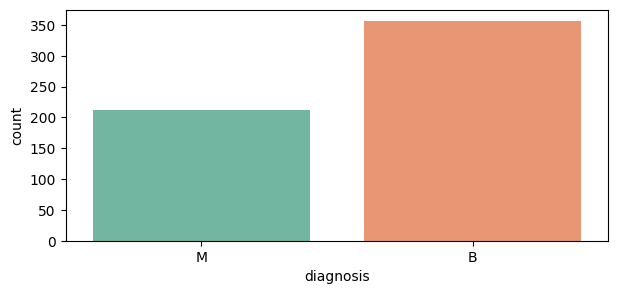

In [38]:
plt.figure(figsize=(7,3))
sns.countplot(x = 'diagnosis' , data =data , palette = "Set2")
plt.show()

In [39]:
data.drop_duplicates(inplace =True)
data.shape

(569, 31)

In [40]:
data["diagnosis"] = data["diagnosis"].map({"M" : 1 , "B" : 0})
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [41]:
X = data.drop("diagnosis" , axis = 1)
X.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [42]:
y = data["diagnosis"]
y.head()

0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

In [43]:
from sklearn.model_selection import train_test_split
X_train , X_test ,y_train , y_test  = train_test_split(X , y , test_size =0.2 , random_state = 0, stratify = y )
X_train.shape ,X_test.shape , y_train.shape , y_test.shape

((455, 30), (114, 30), (455,), (114,))

In [44]:
from sklearn.preprocessing import MinMaxScaler 
scaler = MinMaxScaler ()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [47]:
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , InputLayer

In [48]:
ann =  Sequential()
ann.add(InputLayer(input_shape = (30,)))
ann.add(Dense(26 , activation = "relu"))
ann.add(Dense(15 , activation = "relu"))
ann.add(Dense(1 , activation = "sigmoid"))
ann.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 26)                806       
                                                                 
 dense_1 (Dense)             (None, 15)                405       
                                                                 
 dense_2 (Dense)             (None, 1)                 16        
                                                                 
Total params: 1,227
Trainable params: 1,227
Non-trainable params: 0
_________________________________________________________________


In [50]:
ann.compile(loss = 'binary_crossentropy' , optimizer = 'adam' , metrics = ['accuracy'])


In [ ]:
ann.fit(X_train ,y_train , epochs = 100 , validation_data = (X_test , y_test))

Epoch 1/100
15/15 [==============================] - 1s 12ms/step - loss: 0.6841 - accuracy: 0.4527 - val_loss: 0.6786 - val_accuracy: 0.5000
Epoch 2/100
15/15 [==============================] - 0s 3ms/step - loss: 0.6468 - accuracy: 0.7648 - val_loss: 0.6353 - val_accuracy: 0.7632
Epoch 3/100
15/15 [==============================] - 0s 3ms/step - loss: 0.6081 - accuracy: 0.8286 - val_loss: 0.5898 - val_accuracy: 0.7895
Epoch 4/100
15/15 [==============================] - 0s 3ms/step - loss: 0.5600 - accuracy: 0.8418 - val_loss: 0.5330 - val_accuracy: 0.8246
Epoch 5/100
15/15 [==============================] - 0s 2ms/step - loss: 0.5035 - accuracy: 0.8725 - val_loss: 0.4758 - val_accuracy: 0.8684
Epoch 6/100
15/15 [==============================] - 0s 3ms/step - loss: 0.4491 - accuracy: 0.8747 - val_loss: 0.4223 - val_accuracy: 0.8860
Epoch 7/100
15/15 [==============================] - 0s 3ms/step - loss: 0.4001 - accuracy: 0.8857 - val_loss: 0.3789 - val_accuracy: 0.8947
Epoch 8/100


<Axes: >

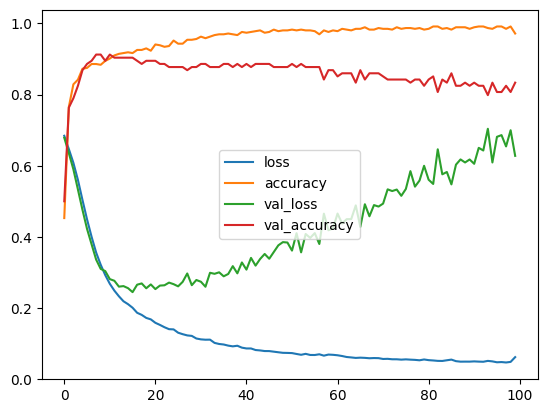

In [53]:
model_loss = pd.DataFrame(ann.history.history)
model_loss.plot()

In [60]:
from tensorflow.keras.callbacks import EarlyStopping
es = EarlyStopping(monitor = "val_loss" , mode = "min" , verbose = 1 , patience = 50)
ann.fit(X_train , y_train , epochs = 100 , validation_data = (X_test , y_test) ,callbacks = [es])

Epoch 1/100
15/15 [==============================] - 0s 9ms/step - loss: 0.0388 - accuracy: 0.9890 - val_loss: 0.9592 - val_accuracy: 0.7719
Epoch 2/100
15/15 [==============================] - 0s 3ms/step - loss: 0.0384 - accuracy: 0.9912 - val_loss: 0.9463 - val_accuracy: 0.7719
Epoch 3/100
15/15 [==============================] - 0s 2ms/step - loss: 0.0392 - accuracy: 0.9890 - val_loss: 0.9792 - val_accuracy: 0.7632
Epoch 4/100
15/15 [==============================] - 0s 2ms/step - loss: 0.0390 - accuracy: 0.9868 - val_loss: 0.9493 - val_accuracy: 0.7807
Epoch 5/100
15/15 [==============================] - 0s 2ms/step - loss: 0.0465 - accuracy: 0.9846 - val_loss: 0.9935 - val_accuracy: 0.7719
Epoch 6/100
15/15 [==============================] - 0s 3ms/step - loss: 0.0431 - accuracy: 0.9824 - val_loss: 0.8578 - val_accuracy: 0.7982
Epoch 7/100
15/15 [==============================] - 0s 2ms/step - loss: 0.0425 - accuracy: 0.9868 - val_loss: 1.0187 - val_accuracy: 0.7544
Epoch 8/100
1

In [63]:
#save the parameters 
ann.save("breast_cancer.h5")

In [64]:
import pickle
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler , f)

In [65]:
import tensorflow as tf
import pandas as pd
import pickle
from sklearn.preprocessing import MinMaxScaler
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. Load the trained model
# ==========================================

model = tf.keras.models.load_model("breast_cancer.h5")


# ==========================================
# 2. Load the fitted scaler
# ==========================================

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)


# ==========================================
# 3. Prepare input data
# ==========================================

input_data = {
    'radius_mean': [14.0],
    'texture_mean': [20.0],
    'perimeter_mean': [90.0],
    'area_mean': [600.0],
    'smoothness_mean': [0.1],
    'compactness_mean': [0.15],
    'concavity_mean': [0.2],
    'concave points_mean': [0.1],
    'symmetry_mean': [0.2],
    'fractal_dimension_mean': [0.06],

    'radius_se': [0.2],
    'texture_se': [1.0],
    'perimeter_se': [1.5],
    'area_se': [20.0],
    'smoothness_se': [0.005],
    'compactness_se': [0.02],
    'concavity_se': [0.03],
    'concave points_se': [0.01],
    'symmetry_se': [0.03],
    'fractal_dimension_se': [0.004],

    'radius_worst': [16.0],
    'texture_worst': [25.0],
    'perimeter_worst': [105.0],
    'area_worst': [800.0],
    'smoothness_worst': [0.12],
    'compactness_worst': [0.2],
    'concavity_worst': [0.3],
    'concave points_worst': [0.15],
    'symmetry_worst': [0.25],
    'fractal_dimension_worst': [0.08]
}


# ==========================================
# 4. Convert input data to DataFrame
# ==========================================

input_df = pd.DataFrame(input_data)


# ==========================================
# 5. Check expected features
# ==========================================

expected_features = scaler.feature_names_in_

print("Number of features expected:", len(expected_features))
print("Number of features provided:", len(input_df.columns))


# Find missing features
missing_features = set(expected_features) - set(input_df.columns)

# Find extra features
extra_features = set(input_df.columns) - set(expected_features)


if missing_features:
    raise ValueError(
        f"Missing features in input data: {missing_features}"
    )

if extra_features:
    raise ValueError(
        f"Extra features in input data: {extra_features}"
    )


# ==========================================
# 6. Arrange columns in training order
# ==========================================

input_df = input_df[expected_features]


print("\nInput columns arranged correctly:")
print(input_df.columns.tolist())


# ==========================================
# 7. Scale input data
# ==========================================

input_array = scaler.transform(input_df)


# ==========================================
# 8. Make prediction
# ==========================================

predictions = model.predict(input_array, verbose=0)


# ==========================================
# 9. Convert probability to class
# ==========================================

predicted_classes = (predictions > 0.5).astype("int32")


# ==========================================
# 10. Map class labels
# ==========================================

class_mapping = {
    0: "Benign",
    1: "Malignant"
}


predicted_class_names = [
    class_mapping[int(label[0])]
    for label in predicted_classes
]


# ==========================================
# 11. Display result
# ==========================================

print("\nPrediction Probability:", predictions[0][0])
print("Predicted Class:", predicted_classes[0][0])
print("Predicted Class Name:", predicted_class_names[0])

Number of features expected: 30
Number of features provided: 30

Input columns arranged correctly:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Prediction Probability: 0.9979795
Predicted Class: 1
Predicted Class Name: Malignant
